# Data Loading and preprocessing

In [18]:
import mne
import numpy as np
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [19]:
# Set dataset path
dataset_path = Path('/home/aloo/CNS_Summer_Project_1/Infants_data')

# Get list of all subjects
subjects = sorted([d for d in os.listdir(dataset_path) if d.startswith('sub-NORB')])
print(f"Found {len(subjects)} subjects")

Found 103 subjects


In [20]:
# Function to find EDF files for a subject
def find_edf_files(subject_id):
    """Find all EDF files for a given subject."""
    subject_path = dataset_path / subject_id
    edf_files = []
    
    if subject_path.exists():
        # Search for EDF files in subject directory
        edf_files = list(subject_path.rglob('*.edf'))
    
    return edf_files

# Test with first subject
test_subject = subjects[68]
edf_files = find_edf_files(test_subject)
print(f"\n{test_subject}:")
print(f"  Found {len(edf_files)} EDF file(s)")
for edf in edf_files:
    print(f"  - {edf.name}")


sub-NORB00069:
  Found 4 EDF file(s)
  - sub-NORB00069_ses-2_task-EEG_eeg.edf
  - sub-NORB00069_ses-1_task-EEG_eeg.edf
  - sub-NORB00069_ses-3_task-EEG_eeg.edf
  - sub-NORB00069_ses-4_task-EEG_eeg.edf


In [21]:
# Function to load EDF file
def load_edf_data(edf_path):
    """
    Load EDF file with MNE and extract EEG channels.
    
    Parameters:
    -----------
    edf_path : str or Path
        Path to the EDF file
        
    Returns:
    --------
    raw : mne.io.Raw
        Raw EEG data
    """
    # Load the EDF file
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    # Get info
    n_channels = len(raw.ch_names)
    sampling_rate = raw.info['sfreq']
    duration = raw.times[-1]
    
    print(f"\nLoaded: {Path(edf_path).name}")
    # print(f"  Channels: {n_channels}")
    # print(f"  Sampling rate: {sampling_rate} Hz")
    # print(f"  Duration: {duration:.2f} seconds")
    # print(f"  Channel names: {raw.ch_names}")
    
    return raw

# Load the first EDF file as a test
if edf_files:
    raw = load_edf_data(edf_files[0])
else:
    print("No EDF files found for testing")


Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf


In [22]:
# # Extract EEG data as numpy array
# if 'raw' in locals():
#     # Get the data
#     data = raw.get_data()  # Shape: (n_channels, n_timepoints)
#     sampling_rate = raw.info['sfreq']
#     channel_names = raw.ch_names
    
#     print(f"\nExtracted data shape: {data.shape}")
#     print(f"  Number of channels: {data.shape[0]}")
#     print(f"  Number of timepoints: {data.shape[1]}")
#     print(f"  Duration: {data.shape[1] / sampling_rate:.2f} seconds")

In [23]:
# Detect and remove bad channels
def detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-2):
    """
    Detect bad channels (flat or extremely noisy).
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    flat_threshold : float
        Threshold for flat channels (std < threshold)
    noise_threshold : float
        Threshold for noisy channels (std > threshold)
        
    Returns:
    --------
    bad_channels : list
        List of bad channel names
    """
    data = raw.get_data()
    channel_names = raw.ch_names
    bad_channels = []
    
    # Define reference/ground channel names to exclude
    ref_ground_channels = {'PG1', 'PG2', 'REF', 'GND', 'GROUND', '25+', '26+', '27+'}
    
    for i, ch_name in enumerate(channel_names):
        ch_data = data[i, :]
        ch_std = np.std(ch_data)
        ch_range = np.max(ch_data) - np.min(ch_data)
        
        is_bad = False
        
        # Check if flat
        if ch_std < flat_threshold:
            is_bad = True
        
        # Check if too noisy
        elif ch_std > noise_threshold:
            is_bad = True
        
        # Check if constant value
        elif ch_range == 0:
            is_bad = True
        
        # Check for reference/ground channels
        elif ch_name.upper() in ref_ground_channels:
            is_bad = True
        
        if is_bad:
            bad_channels.append(ch_name)
    
    # print(f"\nFound {len(bad_channels)} bad channel(s): {bad_channels}")
    
    return bad_channels

# Detect bad channels
if 'raw' in locals():
    bad_channels = detect_bad_channels(raw)
    
    # Remove bad channels if any found
    if bad_channels:
        raw_clean = raw.copy()
        raw_clean.drop_channels(bad_channels)
        print(f"\nRemoved {len(bad_channels)} bad channel(s)")
        print(f"Remaining channels ({len(raw_clean.ch_names)}): {raw_clean.ch_names}")
    else:
        raw_clean = raw.copy()
        print("\nNo bad channels detected. Proceeding with all channels.")
    
    # Create raw_filtered alias (data is already filtered at acquisition)
    raw_filtered = raw_clean  # For compatibility with downstream code
else:
    print("Error: 'raw' data not found. Please run Step 1 first.")


No bad channels detected. Proceeding with all channels.


In [24]:
# Segment data based on annotation file
def load_annotations(subject_id, session_id, dataset_path):
    """
    Load annotation file for a given subject and session.
    Handles TSV files with trailing tabs/whitespace robustly.
    
    Parameters:
    -----------
    subject_id : str
        Subject ID (e.g., 'sub-NORB00001')
    session_id : str
        Session ID (e.g., 'ses-1')
    dataset_path : Path
        Path to dataset directory
        
    Returns:
    --------
    annotations_df : pd.DataFrame or None
        DataFrame with columns: onset, duration, label
    """
    annotations_path = dataset_path / 'derivatives' / 'NeuronicEEG' / subject_id / session_id / 'eeg' / f'{subject_id}_{session_id}_task-EEG_annotations.tsv'
    
    if annotations_path.exists():
        # Read file line by line to handle trailing tabs properly
        with open(annotations_path, 'r') as f:
            lines = f.readlines()
        
        # Parse manually to avoid pandas issues with trailing tabs
        data = []
        header = None
        
        for i, line in enumerate(lines):
            # Split by tab and strip whitespace from each field
            fields = [field.strip() for field in line.strip().split('\t')]
            
            if i == 0:
                # Header row
                header = fields[:3]  # Only take first 3 columns: onset, duration, label
            else:
                # Data row - only take first 3 fields
                if len(fields) >= 3 and fields[0] and fields[1]:  # Ensure we have onset and duration
                    try:
                        onset = float(fields[0])
                        duration = float(fields[1])
                        label = fields[2] if fields[2] else 'eyes_closed'  # Default if empty
                        data.append([onset, duration, label])
                    except ValueError:
                        continue  # Skip malformed lines
        
        if data:
            annotations_df = pd.DataFrame(data, columns=['onset', 'duration', 'label'])
            return annotations_df
        else:
            print(f"  Warning: No valid data in annotations file: {annotations_path}")
            return None
    else:
        print(f"  Warning: No annotations file found at {annotations_path}")
        return None

def segment_data_from_annotations(raw, annotations_df, label='eyes_closed'):
    """
    Segment EEG data based on annotations file.
    Only extracts segments marked with the specified label (e.g., 'eyes_closed').
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    annotations_df : pd.DataFrame
        DataFrame with columns: onset, duration, label
    label : str
        Label to filter segments by (default: 'eyes_closed')
        
    Returns:
    --------
    segments : list of numpy arrays
        List of data segments, each with shape (n_channels, n_samples_per_segment)
    segment_info : list of dict
        List of dictionaries containing segment metadata (onset, duration)
    """
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    n_channels, n_samples = data.shape
    
    # Filter annotations by label (case-insensitive + Spanish support)
    # Accept both 'eyes_closed' and Spanish 'ojos_cerrados'
    label_lower = label.lower()
    filtered_annotations = annotations_df[
        (annotations_df['label'].str.lower() == label_lower) |
        (annotations_df['label'].str.lower() == 'ojos_cerrados') |
        (annotations_df['label'].str.lower() == 'vigilia_ojos_abiertos') |
        (annotations_df['label'].str.lower() == 'sue o_espontaneo')
    ]
    
    segments = []
    segment_info = []
    
    # print(f"\nSegmenting data from annotations file...")
    # print(f"  Total annotations: {len(annotations_df)}")
    # print(f"  Unique labels found: {annotations_df['label'].unique().tolist()}")
    # print(f"  Annotations matching '{label}' {len(filtered_annotations)}")
    
    for idx, row in filtered_annotations.iterrows():
        onset = row['onset']  # in seconds
        duration = row['duration']  # in seconds
        
        # Convert to sample indices
        start_sample = int(onset * sfreq)
        end_sample = int((onset + duration) * sfreq)
        
        # Check if segment is within bounds
        if start_sample >= 0 and end_sample <= n_samples:
            segment = data[:, start_sample:end_sample]
            segments.append(segment)
            segment_info.append({
                'onset': onset,
                'duration': duration,
                'start_sample': start_sample,
                'end_sample': end_sample
            })
        else:
            print(f"  Warning: Segment at onset={onset}s exceeds data bounds, skipping")
    
    # print(f"\nExtracted {len(segments)} valid segments")
    
    return segments, segment_info

# Apply segmentation based on annotations
if 'raw_clean' in locals():
    # Extract subject and session info from the loaded EDF file
    if 'edf_files' in locals() and edf_files:
        edf_name = edf_files[0].stem
        parts = edf_name.split('_')
        subject_id = parts[0]  # e.g., 'sub-NORB00042'
        session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'
        
        # Load annotations
        annotations_df = load_annotations(subject_id, session_id, dataset_path)
        
        if annotations_df is not None:
            # Segment data based on annotations
            segments, segment_info = segment_data_from_annotations(raw_clean, annotations_df, label='eyes_closed')
            
            if len(segments) > 0:
                print(f"\n✓ Successfully segmented data for {subject_id} {session_id}")
            else:
                print(f"\n⚠ No valid segments found for {subject_id} {session_id}")
        else:
            print(f"\n⚠ Could not load annotations. Skipping segmentation.")
    else:
        print("Error: EDF file information not found.")
else:
    print("Error: 'raw_clean' data not found. Please run bad channel detection first.")


✓ Successfully segmented data for sub-NORB00069 ses-2


# Correlation calculation and visualisation

In [25]:
# Function to calculate average Pearson correlation matrix across epochs (segments)
def compute_average_pearson_correlation(segments, channel_names, save_path=None):
    """
    Compute the average Pearson correlation matrix across all segments (epochs).
    
    Parameters:
    -----------
    segments : list of np.ndarray
        List of EEG data segments, each of shape (n_channels, n_timepoints)
    channel_names : list of str
        List of channel names for DataFrame index/columns
    save_path : str or None
        If provided, save the averaged correlation matrix as CSV to this path
    
    Returns:
    --------
    avg_corr : np.ndarray
        Averaged correlation matrix (n_channels x n_channels)
    corr_df : pd.DataFrame
        DataFrame of the averaged correlation matrix
    """
    n_channels = segments[0].shape[0]
    corr_matrices = []
    for seg in segments:
        if seg.shape[1] > 1:  # Need at least 2 timepoints
            corr = np.corrcoef(seg)
            corr_matrices.append(corr)
    if corr_matrices:
        avg_corr = np.mean(corr_matrices, axis=0)
        corr_df = pd.DataFrame(avg_corr, index=channel_names, columns=channel_names)
        if save_path is not None:
            corr_df.to_csv(save_path)
            # print(f"Averaged correlation matrix saved to {save_path}")
            # print(avg_corr.shape)
        return avg_corr, corr_df
    else:
        print("No valid segments for correlation calculation.")
        return None, None

# Calculate Pearson correlation for all epochs (segments)
if 'segments' in locals() and len(segments) > 0:
    avg_corr, corr_df = compute_average_pearson_correlation(segments, raw_clean.ch_names, save_path="correlation_matrix_avg.csv")
else:
    print("No valid segments found. Please run segmentation first.")

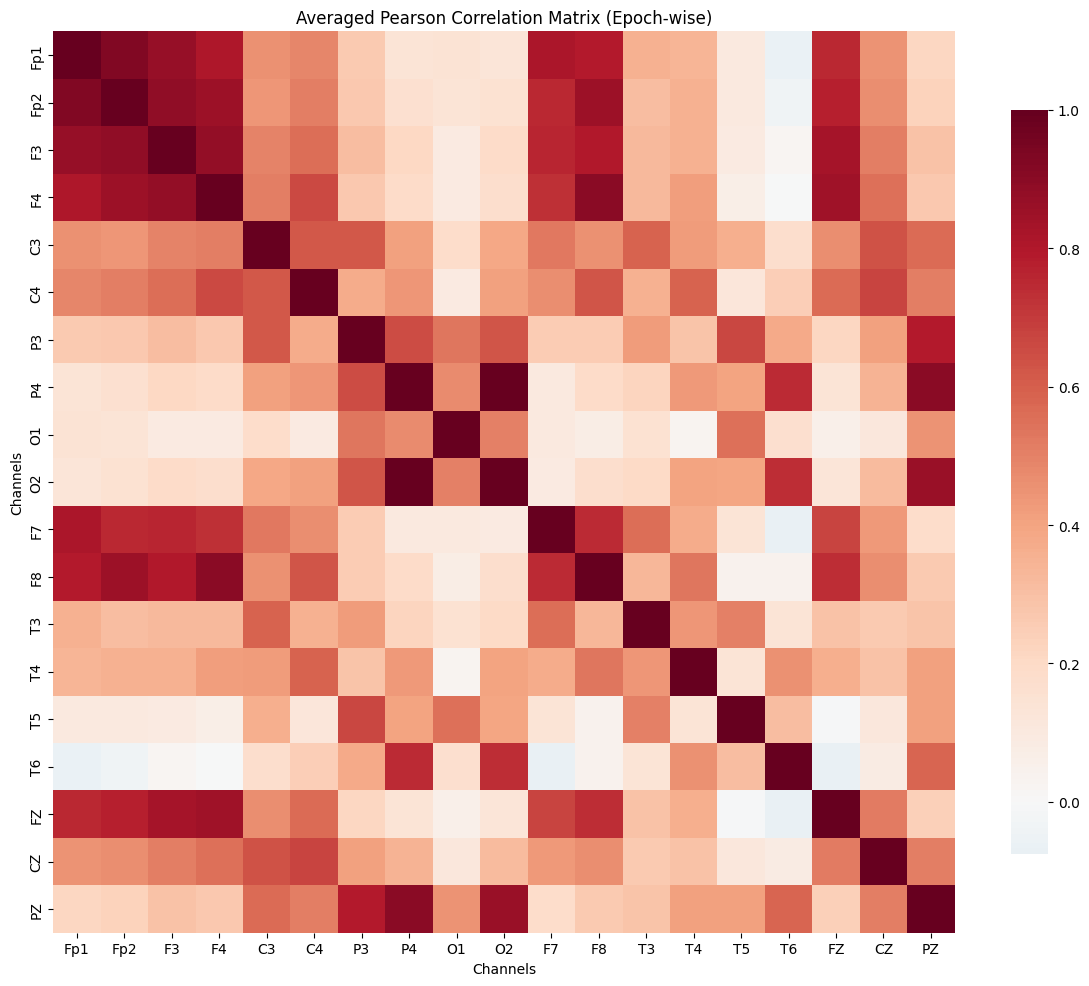

In [26]:
# Visualize the averaged correlation matrix
corr_df = pd.read_csv("correlation_matrix_avg.csv", index_col=0)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, cmap='RdBu_r', center=0, annot=False, square=True, cbar_kws={"shrink": 0.8})
plt.title("Averaged Pearson Correlation Matrix (Epoch-wise)")
plt.xlabel("Channels")
plt.ylabel("Channels")
plt.tight_layout()
plt.show()

# Batch Processing

In [27]:
# Output directory for correlation matrices
output_dir = Path("correlation_matrices_all_subjects")
output_dir.mkdir(exist_ok=True)

for subject_id in subjects:
    subject_path = dataset_path / subject_id
    if not subject_path.exists():
        continue
    # Find all session folders for the subject
    session_dirs = [d for d in subject_path.iterdir() if d.is_dir() and d.name.startswith('ses-')]
    if not session_dirs:
        session_dirs = [Path('ses-1')]  # Default to 'ses-1' if not found
    for session_dir in session_dirs:
        session_id = session_dir.name
        edf_files = list((subject_path / session_id).rglob('*.edf'))
        if not edf_files:
            continue
        edf_path = edf_files[0]  # Use the first EDF file found
        try:
            raw = load_edf_data(edf_path)
            bad_channels = detect_bad_channels(raw)
            raw_clean = raw.copy()
            if bad_channels:
                raw_clean.drop_channels(bad_channels)
            # Load annotations
            annotations_df = load_annotations(subject_id, session_id, dataset_path)
            if annotations_df is not None:
                segments, segment_info = segment_data_from_annotations(raw_clean, annotations_df, label='eyes_closed')
                if segments:
                    save_path = output_dir / f"{subject_id}_{session_id}_correlation_matrix_avg.csv"
                    compute_average_pearson_correlation(segments, raw_clean.ch_names, save_path=save_path)
                else:
                    print(f"No valid segments for {subject_id} {session_id}")
            else:
                print(f"No annotations for {subject_id} {session_id}")
        except Exception as e:
            print(f"Error processing {subject_id} {session_id}: {e}")


Loaded: sub-NORB00001_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00002_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00003_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00004_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00005_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00006_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00007_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00008_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00009_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00010_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00011_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00012_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00013_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00014_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00015_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00016_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00017_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00018_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00019_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00020_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00021_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00022_ses-1_task-

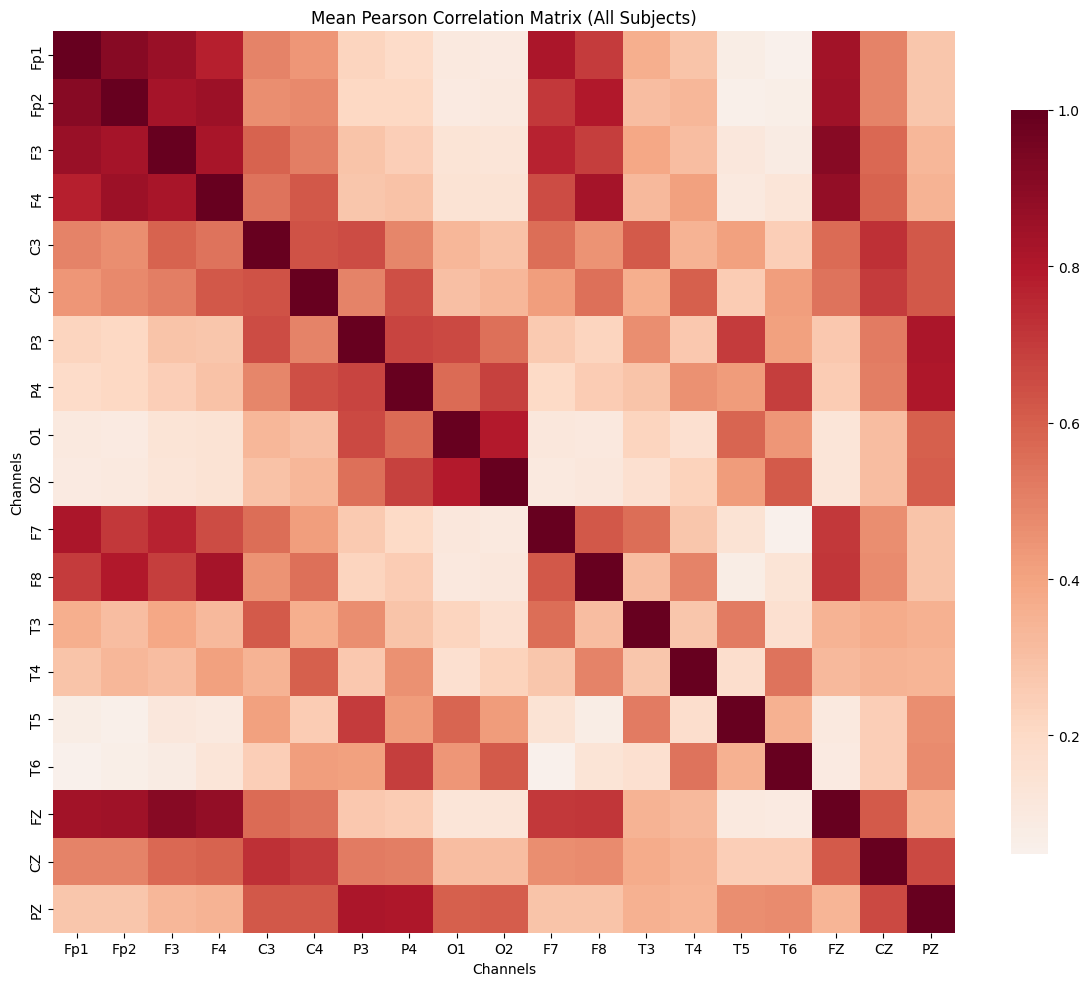

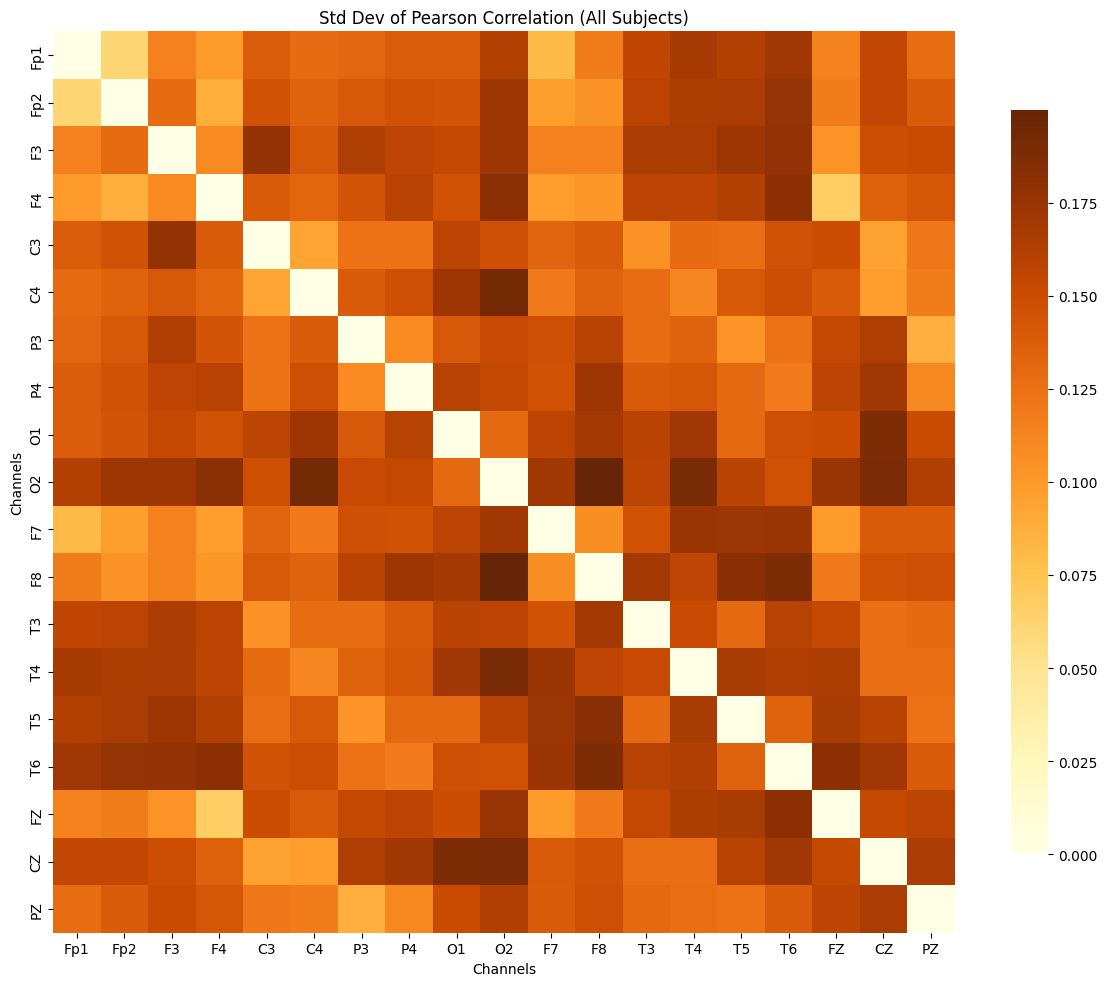

In [28]:
# Visualize and compare correlation matrices across all subjects

# Path to batch results
glob_path = str(output_dir / "*_correlation_matrix_avg.csv")
result_files = sorted(glob.glob(glob_path))

# Load all correlation matrices
def load_all_correlation_matrices(file_list):
    matrices = []
    for f in file_list:
        df = pd.read_csv(f, index_col=0)
        matrices.append(df.values)
    return np.array(matrices), df.index.tolist()

all_corrs, channel_names = load_all_correlation_matrices(result_files)

# Compute mean and std matrices
mean_corr = np.mean(all_corrs, axis=0)
std_corr = np.std(all_corrs, axis=0)

# Plot mean correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(mean_corr, xticklabels=channel_names, yticklabels=channel_names, cmap='RdBu_r', center=0, annot=False, square=True, cbar_kws={"shrink": 0.8})
plt.title("Mean Pearson Correlation Matrix (All Subjects)")
plt.xlabel("Channels")
plt.ylabel("Channels")
plt.tight_layout()
plt.show()

# Plot std deviation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(std_corr, xticklabels=channel_names, yticklabels=channel_names, cmap='YlOrBr', annot=False, square=True, cbar_kws={"shrink": 0.8})
plt.title("Std Dev of Pearson Correlation (All Subjects)")
plt.xlabel("Channels")
plt.ylabel("Channels")
plt.tight_layout()
plt.show()

In [29]:
# Calculate Pearson correlation for all segments of all sessions for the test subject
all_session_corrs = []
all_session_names = []

subject_id = test_subject
subject_path = dataset_path / subject_id
session_dirs = [d for d in subject_path.iterdir() if d.is_dir() and d.name.startswith('ses-')]
if not session_dirs:
    session_dirs = [Path('ses-1')]

for session_dir in session_dirs:
    session_id = session_dir.name
    edf_files = list((subject_path / session_id).rglob('*.edf'))
    if not edf_files:
        continue
    edf_path = edf_files[0]
    try:
        raw = load_edf_data(edf_path)
        bad_channels = detect_bad_channels(raw)
        raw_clean = raw.copy()
        if bad_channels:
            raw_clean.drop_channels(bad_channels)
        # Load annotations
        annotations_df = load_annotations(subject_id, session_id, dataset_path)
        if annotations_df is not None:
            segments, segment_info = segment_data_from_annotations(raw_clean, annotations_df, label='eyes_closed')
            for i, seg in enumerate(segments):
                if seg.shape[1] > 1:
                    corr = np.corrcoef(seg)
                    all_session_corrs.append(corr)
                    all_session_names.append(f"{session_id}_segment_{i+1}")
    except Exception as e:
        print(f"Error processing {subject_id} {session_id}: {e}")

print(f"Computed correlation matrices for {len(all_session_corrs)} segments of {subject_id}.")


Loaded: sub-NORB00069_ses-4_task-EEG_eeg.edf

Loaded: sub-NORB00069_ses-3_task-EEG_eeg.edf

Loaded: sub-NORB00069_ses-1_task-EEG_eeg.edf

Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf
Computed correlation matrices for 70 segments of sub-NORB00069.


In [30]:
# Remove the lower triangular part (including diagonal) from all correlation matrices
import numpy as np

all_session_corrs_upper = []
for corr in all_session_corrs:
    corr_upper = corr.copy()
    corr_upper[np.tril_indices_from(corr_upper)] = np.nan  # Set lower triangle and diagonal to NaN
    all_session_corrs_upper.append(corr_upper)

print(f"Lower triangular part removed (set to NaN) for {len(all_session_corrs_upper)} matrices.")

Lower triangular part removed (set to NaN) for 70 matrices.


# Correlation Matrix Analyses

In [31]:
# Setup: load male/female correlation matrices
participants_df = pd.read_csv(dataset_path / 'participants.tsv', sep='\t')
male_subjects = set(participants_df[participants_df['sex'] == 'M']['participant_id'])
female_subjects = set(participants_df[participants_df['sex'] == 'F']['participant_id'])

male_files = [f for f in result_files if Path(f).name.split('_ses')[0] in male_subjects]
female_files = [f for f in result_files if Path(f).name.split('_ses')[0] in female_subjects]

male_corrs, male_ch = load_all_correlation_matrices(male_files)
female_corrs, female_ch = load_all_correlation_matrices(female_files)
male_mean = np.mean(male_corrs, axis=0)
female_mean = np.mean(female_corrs, axis=0)

print(f"Male subjects: {len(male_files)}, Female subjects: {len(female_files)}")

Male subjects: 78, Female subjects: 51


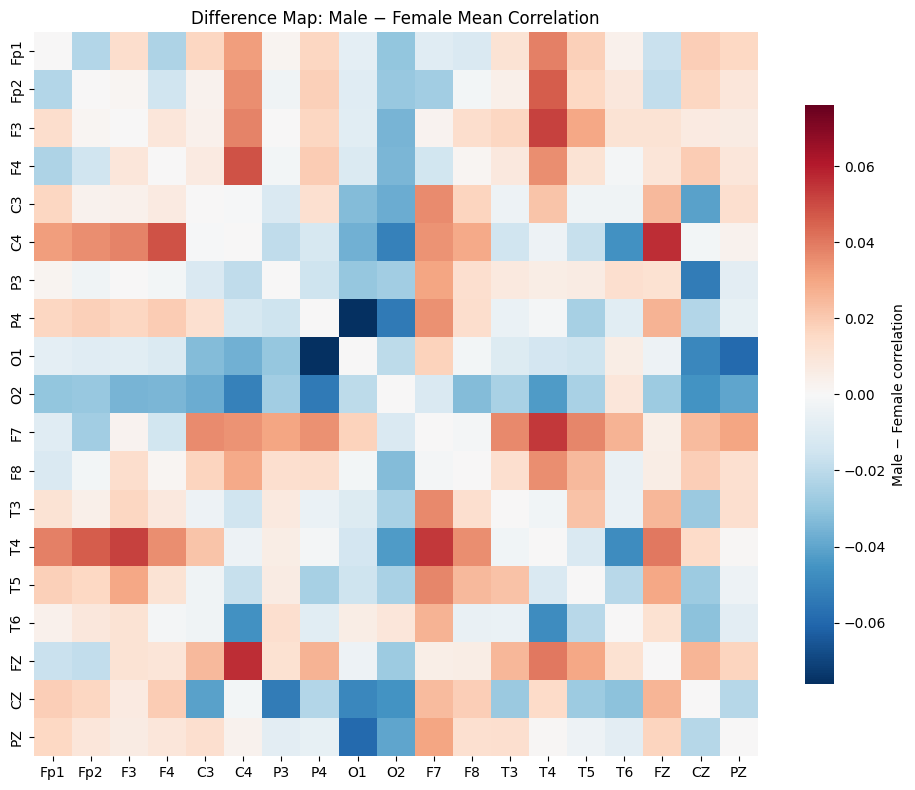

Top 5 channel pairs with biggest Male−Female difference:
  P4 -- O1: -0.0761
  O1 -- PZ: -0.0591
  C4 -- FZ: +0.0564
  F7 -- T4: +0.0540
  P4 -- O2: -0.0535


In [32]:
# 1. Male - Female difference map
# Positive = male stronger connection, Negative = female stronger
diff = male_mean - female_mean
abs_max = np.max(np.abs(diff))

plt.figure(figsize=(10, 8))
sns.heatmap(diff, xticklabels=male_ch, yticklabels=male_ch,
            cmap='RdBu_r', center=0, vmin=-abs_max, vmax=abs_max,
            square=True, cbar_kws={"shrink": 0.8, "label": "Male − Female correlation"})
plt.title("Difference Map: Male − Female Mean Correlation")
plt.tight_layout()
plt.show()

# Print the top 5 channel pairs with biggest differences
upper_idx = np.triu_indices(len(male_ch), k=1)
diffs_flat = diff[upper_idx]
sorted_idx = np.argsort(np.abs(diffs_flat))[::-1][:5]
print("Top 5 channel pairs with biggest Male−Female difference:")
for i in sorted_idx:
    r, c = upper_idx[0][i], upper_idx[1][i]
    print(f"  {male_ch[r]} -- {male_ch[c]}: {diff[r, c]:+.4f}")

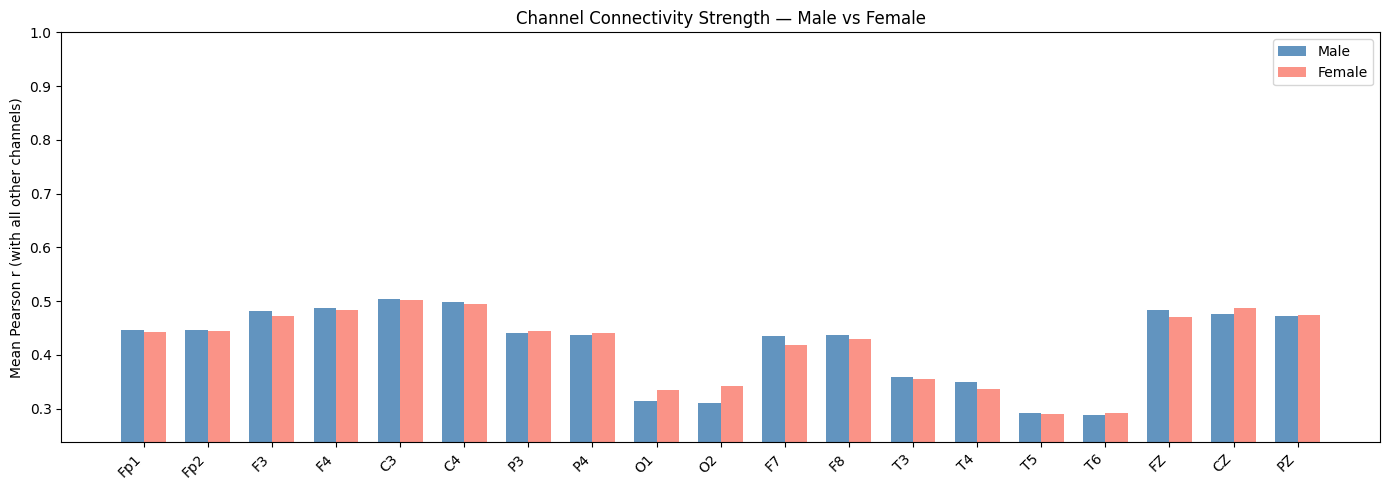

Most connected channel: C3 (avg r = 0.5026)


In [33]:
# 2. Per-channel connectivity strength (mean correlation with all other channels)
# Excludes the diagonal (self-correlation = 1)
n = len(male_ch)
mask = ~np.eye(n, dtype=bool)

male_strength = np.array([male_mean[i, mask[i]].mean() for i in range(n)])
female_strength = np.array([female_mean[i, mask[i]].mean() for i in range(n)])

x = np.arange(n)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_m = ax.bar(x - width/2, male_strength, width, label='Male', color='steelblue', alpha=0.85)
bars_f = ax.bar(x + width/2, female_strength, width, label='Female', color='salmon', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(male_ch, rotation=45, ha='right')
ax.set_ylabel("Mean Pearson r (with all other channels)")
ax.set_title("Channel Connectivity Strength — Male vs Female")
ax.legend()
ax.set_ylim(min(np.concatenate([male_strength, female_strength])) - 0.05, 1.0)
plt.tight_layout()
plt.show()

# Most connected channel overall
overall_strength = (male_strength + female_strength) / 2
top_ch = male_ch[np.argmax(overall_strength)]
print(f"Most connected channel: {top_ch} (avg r = {np.max(overall_strength):.4f})")

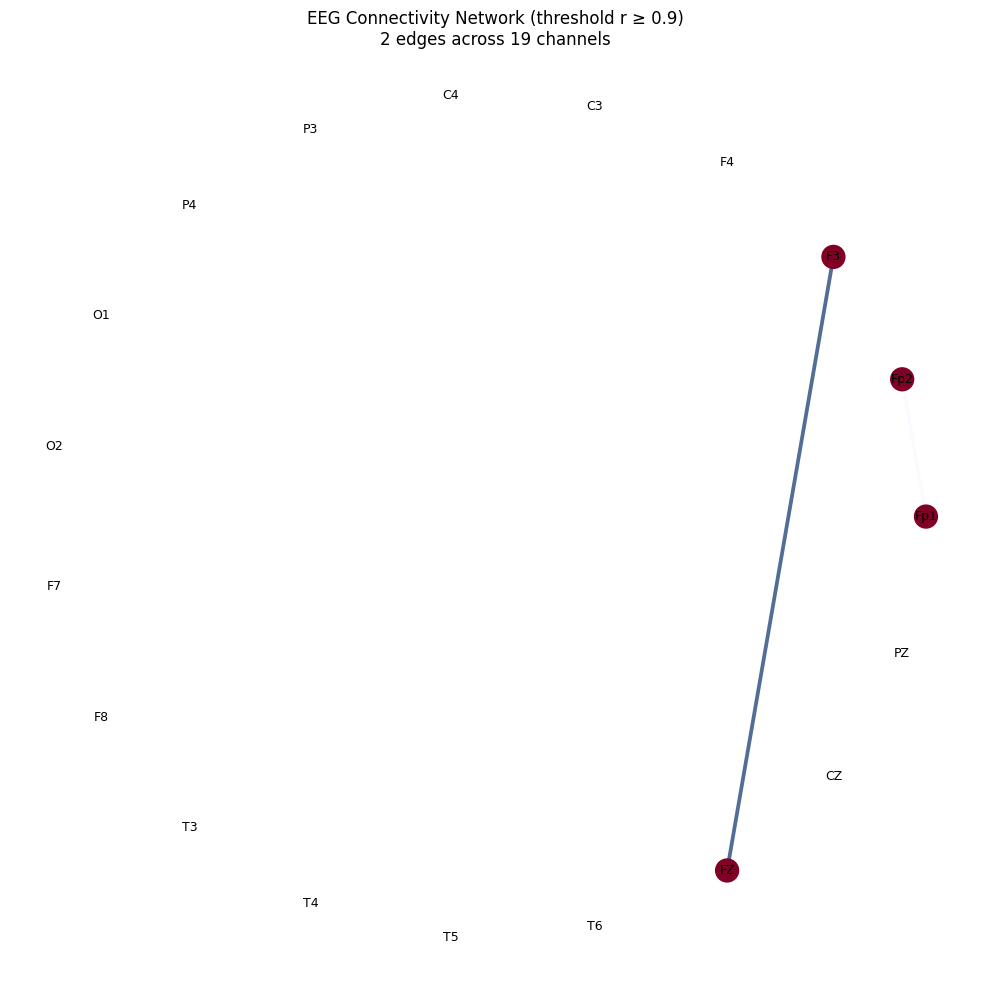

Edges above threshold: 2


In [34]:
# 3. Thresholded connectivity network graph
import networkx as nx

threshold = 0.90  # Only draw edges with r >= threshold
overall_mean = np.mean(all_corrs, axis=0)

G = nx.Graph()
G.add_nodes_from(channel_names)

for i in range(len(channel_names)):
    for j in range(i + 1, len(channel_names)):
        if overall_mean[i, j] >= threshold:
            G.add_edge(channel_names[i], channel_names[j], weight=overall_mean[i, j])

edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
node_strength = [sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()]

pos = nx.circular_layout(G)
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos, node_size=[s * 300 for s in node_strength],
                       node_color=node_strength, cmap='YlOrRd', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w * 3 for w in edge_weights],
                       edge_color=edge_weights, edge_cmap=plt.cm.Blues,
                       alpha=0.7, ax=ax)
ax.set_title(f"EEG Connectivity Network (threshold r ≥ {threshold})\n"
             f"{G.number_of_edges()} edges across {len(channel_names)} channels")
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Edges above threshold: {G.number_of_edges()}")

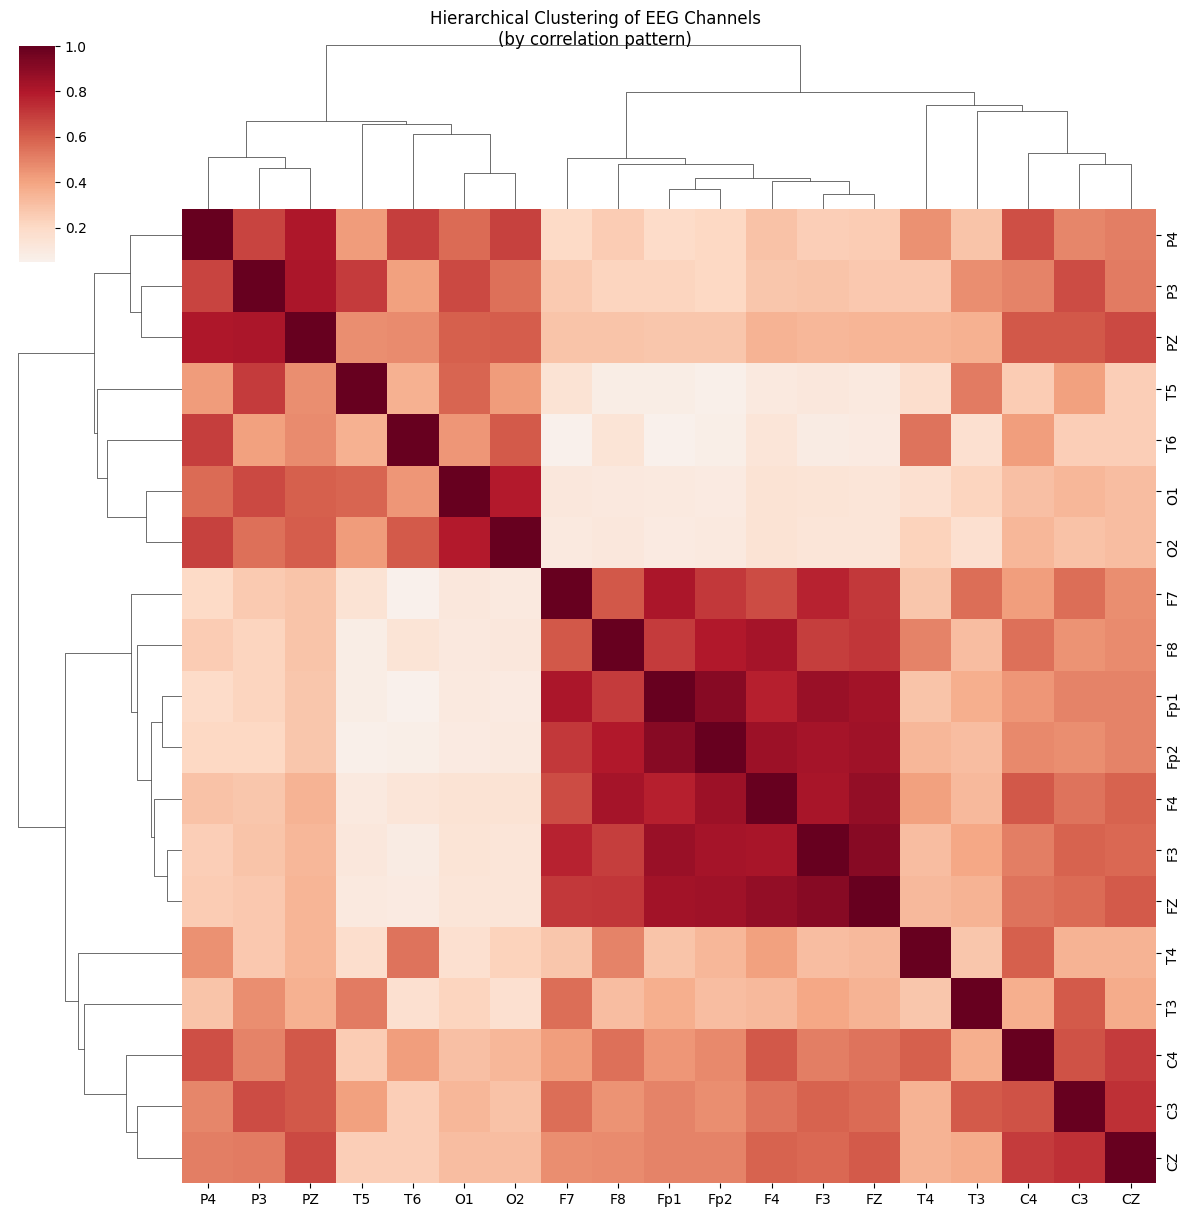

Channel cluster order: ['P4', 'P3', 'PZ', 'T5', 'T6', 'O1', 'O2', 'F7', 'F8', 'Fp1', 'Fp2', 'F4', 'F3', 'FZ', 'T4', 'T3', 'C4', 'C3', 'CZ']


In [35]:
# 4. Hierarchical clustering of channels
# Groups channels that tend to co-activate together
from scipy.cluster.hierarchy import dendrogram, linkage

overall_mean_df = pd.DataFrame(overall_mean, index=channel_names, columns=channel_names)

g = sns.clustermap(overall_mean_df, cmap='RdBu_r', center=0,
                   vmin=overall_mean_df.values.min(), vmax=1.0,
                   figsize=(12, 12), dendrogram_ratio=0.15,
                   cbar_pos=(0.02, 0.8, 0.03, 0.18))
g.fig.suptitle("Hierarchical Clustering of EEG Channels\n(by correlation pattern)", y=1.01)
plt.show()

# Print the cluster order
reordered = [channel_names[i] for i in g.dendrogram_col.reordered_ind]
print("Channel cluster order:", reordered)